# Set up workspace

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy.stats import ttest_ind

In [2]:
import sys
sys.path.append('/glade/u/home/czarakas/coupled_PPE/code/utils')

In [3]:
from load_ensembles import *
from load_gridcell_areas import *
import make_multisimulation_dataset

/glade/u/home/czarakas/.conda/envs/EOF_env/lib/python3.7/site-packages/xarray/core/nputils.py:215: RuntimeWarning: All-NaN slice encountered
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


In [4]:
path_in='/glade/work/czarakas/coupled_PPE/data/data_for_figures/timeseries/'
path_out='/glade/work/czarakas/coupled_PPE/data/data_for_figures/annual_means/'

In [5]:
sys.path.append('/glade/u/home/czarakas/coupled_PPE/code/06_analyze_simulations/generate_figures')

from calculate_annual_means import *
from plotting_settings import *
from FDR_analysis import *

# Load data

### Define variables to load

In [6]:
var='calculated_PREC_FROM_ATM' #'TS'#'calculated_PREC_FROM_ATM'#'TSKIN'
domain='lnd'
ensemble='coupled'
season='Annual'

In [7]:
end_spinup=40

### Load full ensemble data

In [8]:
var_array_withspinup=xr.open_dataset(path_in+var+'_timeseries_'+ensemble+'.nc')

In [9]:
var_array=var_array_withspinup[var][end_spinup*12:,:,:,:]

### Define function for calculating annual averages based on days per year

In [10]:
if ensemble=='offline':
    ensemble_path='offline_simulations'
    refcase_id='OFFL0000_PI_v02'
elif ensemble=='coupled':
    ensemble_path='coupled_simulations'
    refcase_id='COUP0000_PI_SOM'
if domain=='atm':
    domain_suffix='.cam.h0.'
elif domain=='lnd':
    domain_suffix='.clm2.h0.'
    
basecase_lnd=xr.open_dataset('/glade/campaign/cgd/tss/czarakas/CoupledPPE/'+ensemble_path+'/'+
                                 refcase_id+'/'+domain+'/proc/tseries/'+refcase_id+domain_suffix+'timeseries.'+var+'.nc')

# Do calculations

In [11]:
var_array_annual=calculate_annual_timeseries(var_array,season=season)

In [12]:
var_array[0,:,:,0].drop_vars(['ensemble_key']).to_dataset(name=var)

<xarray.Dataset>
Dimensions:                   (lat: 96, lon: 144)
Coordinates:
    time                      object 0089-01-16 12:00:00
  * lat                       (lat) float32 -90.0 -88.10526 ... 88.10526 90.0
  * lon                       (lon) float32 0.0 2.5 5.0 ... 352.5 355.0 357.5
Data variables:
    calculated_PREC_FROM_ATM  (lat, lon) float64 ...

In [13]:
ds_grid=var_array[:,:,:,0].drop_vars(['ensemble_key']).to_dataset(name=var)
var_array_ttest=make_multisimulation_dataset.make_empty_dataarray(ds_grid=ds_grid, var=var, keys=params)
var_array_pval=make_multisimulation_dataset.make_empty_dataarray(ds_grid=ds_grid, var=var, keys=params)

/glade/u/home/czarakas/.conda/envs/EOF_env/lib/python3.7/site-packages/xarray/core/nanops.py:142: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis=axis, dtype=dtype)


In [14]:
for i, param in enumerate(params):
    minkey=crosswalk['Key_short'].values[crosswalk.description==param+', min']
    maxkey=crosswalk['Key_short'].values[crosswalk.description==param+', max']
    min_tseries=var_array_annual[:,:,:,var_array_annual.ensemble_key==minkey].mean(dim='ensemble_key')
    max_tseries=var_array_annual[:,:,:,var_array_annual.ensemble_key==maxkey].mean(dim='ensemble_key')
    
    [tstat, pval] = scipy.stats.ttest_ind(min_tseries, max_tseries, equal_var=False)#, alternative='two-sided')
    var_array_ttest[:,:,i]=tstat
    var_array_pval[:,:,i]=pval

/glade/u/home/czarakas/.conda/envs/EOF_env/lib/python3.7/site-packages/scipy/stats/_distn_infrastructure.py:903: RuntimeWarning: invalid value encountered in greater
  return (a < x) & (x < b)
/glade/u/home/czarakas/.conda/envs/EOF_env/lib/python3.7/site-packages/scipy/stats/_distn_infrastructure.py:903: RuntimeWarning: invalid value encountered in less
  return (a < x) & (x < b)
/glade/u/home/czarakas/.conda/envs/EOF_env/lib/python3.7/site-packages/scipy/stats/_distn_infrastructure.py:1912: RuntimeWarning: invalid value encountered in less_equal
  cond2 = cond0 & (x <= _a)
/glade/u/home/czarakas/.conda/envs/EOF_env/lib/python3.7/site-packages/scipy/stats/_distn_infrastructure.py:903: RuntimeWarning: invalid value encountered in greater
  return (a < x) & (x < b)
/glade/u/home/czarakas/.conda/envs/EOF_env/lib/python3.7/site-packages/scipy/stats/_distn_infrastructure.py:903: RuntimeWarning: invalid value encountered in less
  return (a < x) & (x < b)
/glade/u/home/czarakas/.conda/envs/E

In [15]:
pvals=var_array_pval

pval=pvals[:,:,0]
K = np.sum(~np.isnan(pval).values)
alpha_global=0.05
p_Walker=1-np.power((1-alpha_global),(1/K))

Walker_tests=[]
# Do Walker's test
for i, param in enumerate(params):
    pval=pvals[:,:,i]
    Walker_test=(np.nanmin(pval)<=p_Walker)
    print(Walker_test)
    if Walker_test:
        Walker_tests.append('*')
    else:
        Walker_tests.append('')

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


# Do calculation

In [16]:
#ds_P = xr.open_dataset(path_in+'annual_means/delta_calculated_PRECT_Annual_mean_coupled.nc')['calculated_PRECT']
#var_array_pval=xr.open_dataset('/glade/work/czarakas/coupled_PPE/data/data_for_figures/'+
#                               'annual_means/pval_calculated_PRECT_Annual_mean_coupled.nc')['pval']

#landweights_reindex=landweights2.reindex_like(var_array_pval)

In [17]:
pct_sig_change=((var_array_pval<0.05)*landweights2).sum(dim=['lat','lon'])*100

In [18]:
significant_changes_xr=calculate_sig_changes_FDR(var_array_pval, 
                          K=(landweights.values.flatten()>0).sum())

/glade/u/home/czarakas/.conda/envs/EOF_env/lib/python3.7/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in greater
  


In [19]:
pct_sig_change_FDR=(significant_changes_xr*landweights2).sum(dim=['lat','lon'])*100

# Make figure

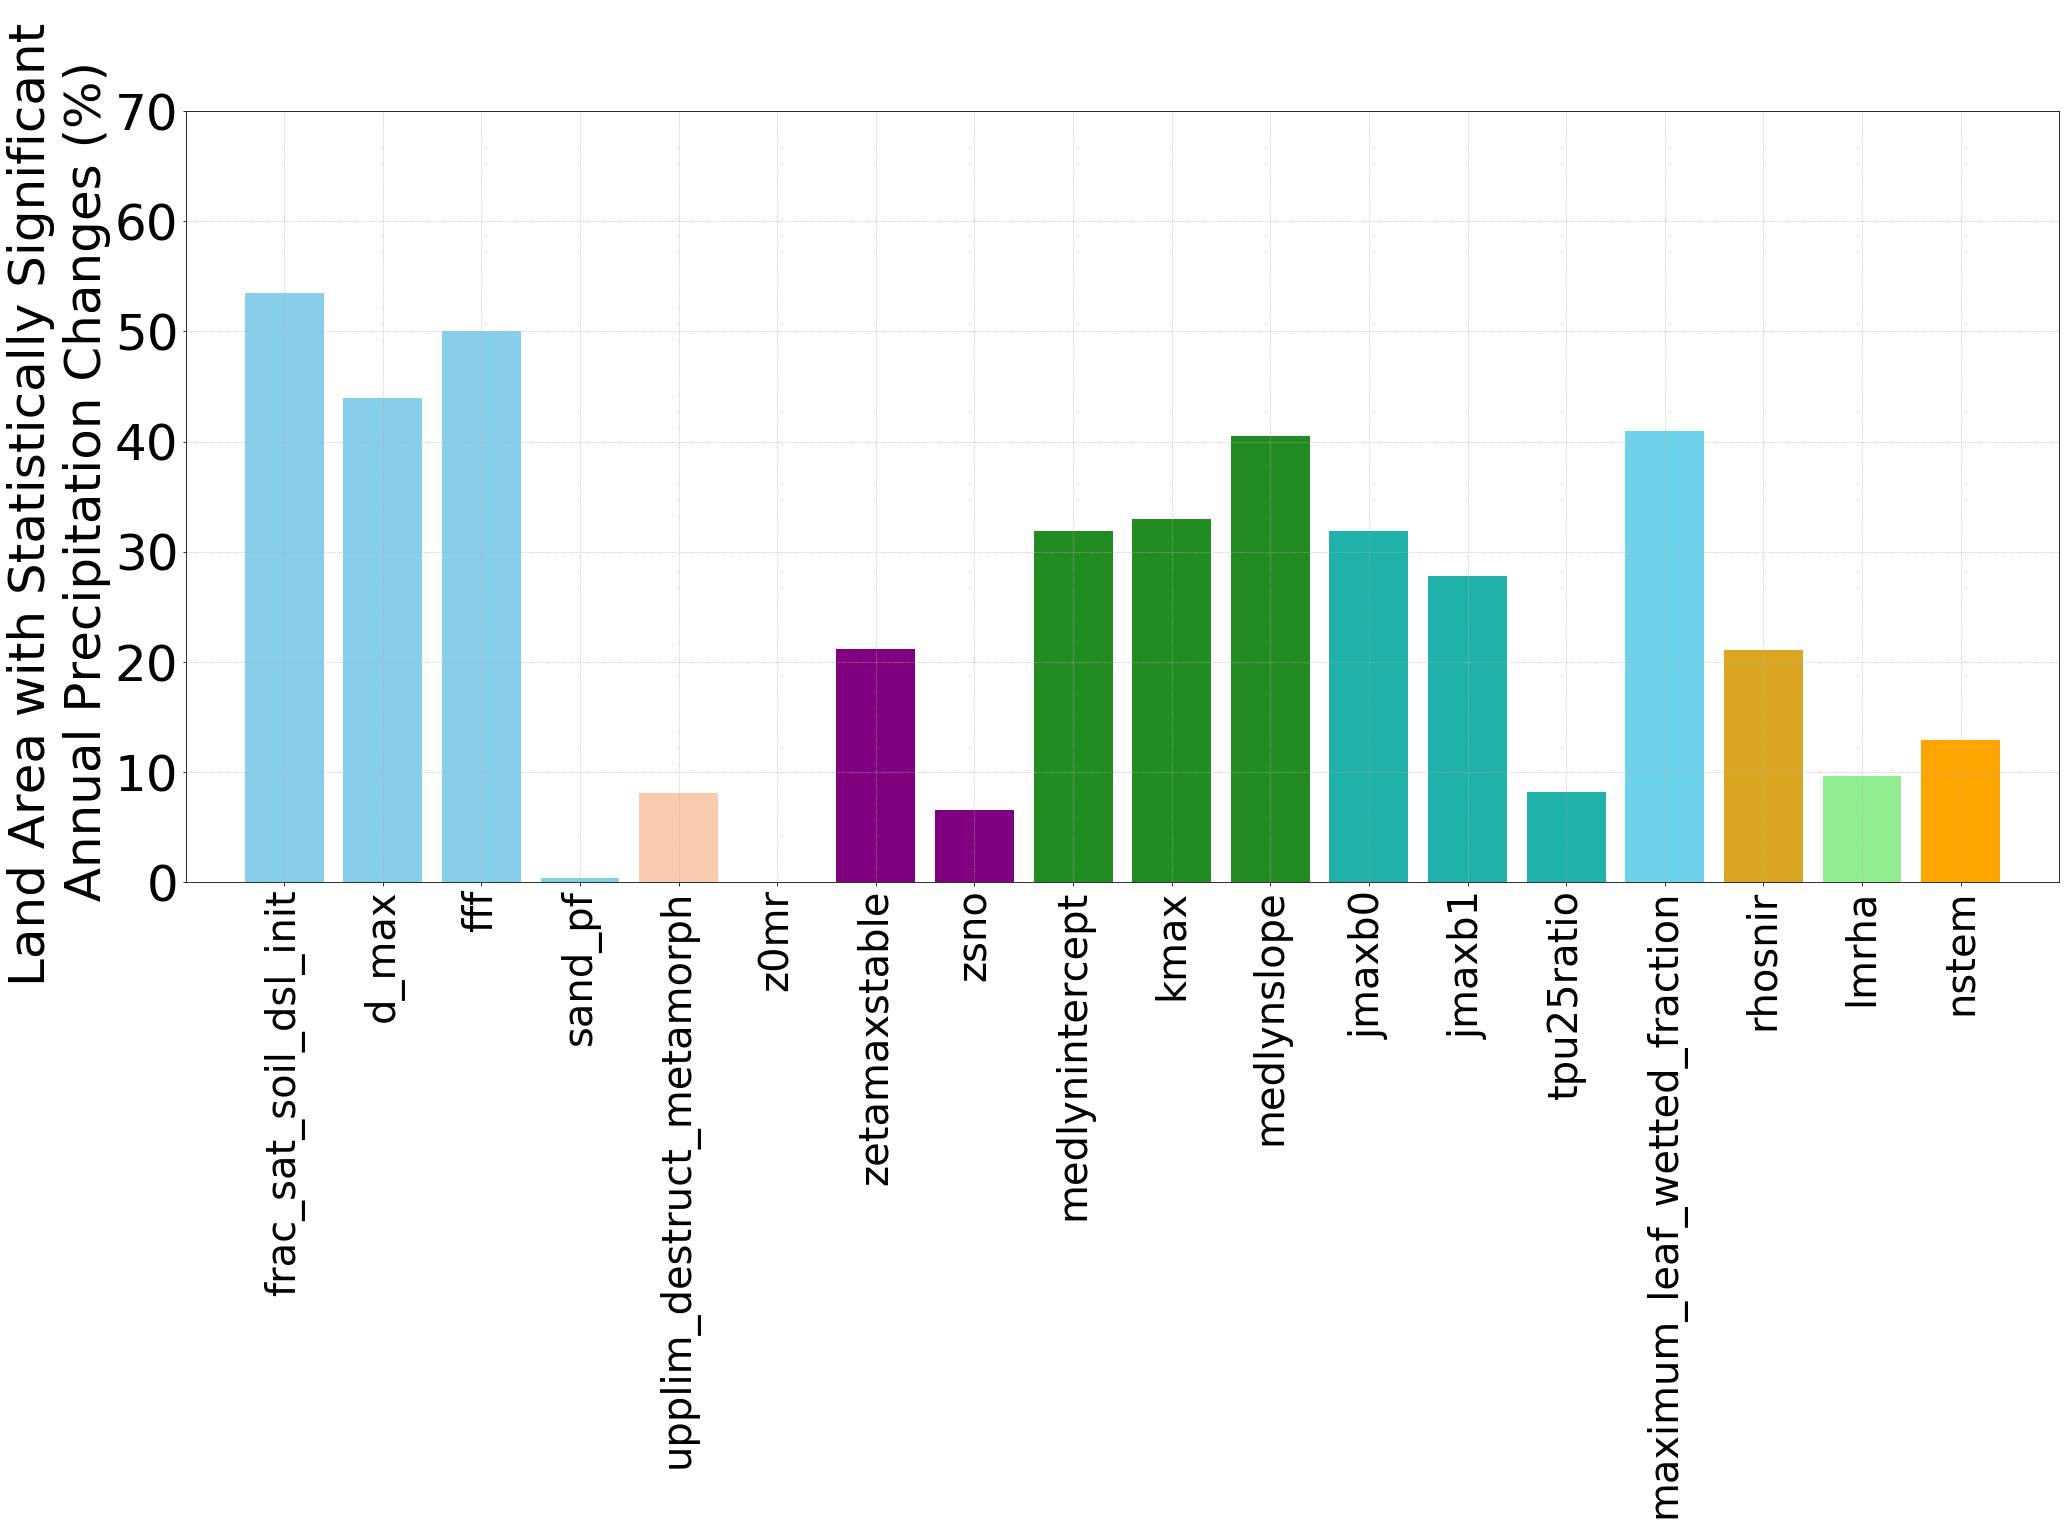

In [20]:
lwidth=6

plt.rcParams.update({'font.size': 50})
plt.figure(figsize=(30,22))
#plt.axhline(y=0,linestyle='--',color='k', linewidth=lwidth)

for i, param in enumerate(params):
    
    plt.bar(i,pct_sig_change_FDR[i], color=param_colors[i])

xticks=plt.xticks(np.arange(0, i+1), params, rotation='vertical',fontsize=40)
plt.grid(linestyle=':')
plt.xlim([-1,np.size(params)])
plt.tight_layout()
plt.ylabel('Land Area with Statistically Significant \n  Annual Precipitation Changes (%)',
          fontsize=50)
plt.ylim([0,70])
plt.tight_layout()
#plt.savefig('Figures/Figure_S_Precip_Change_Significance_by_Parameter.pdf')

# Calculate where changes are significant

In [21]:
ds_grid = basecase_lnd

var_array_ttest = make_multisimulation_dataset.make_empty_dataarray(ds_grid=ds_grid, var=var, keys=keys)
var_array_pval = make_multisimulation_dataset.make_empty_dataarray(ds_grid=ds_grid, var=var, keys=keys)

In [22]:
for i, key in enumerate(var_array.ensemble_key):
    ds_annual=var_array_annual[:,:,:,i]
    [tstat, pval] = scipy.stats.ttest_ind(var_ref_annual, ds_annual, equal_var=False)#, alternative='two-sided')
    var_array_ttest[:,:,i]=tstat
    var_array_pval[:,:,i]=pval

In [23]:
ds_pval=var_array_pval.to_dataset(name='pval')

fname='pval_'+var+'_'+season+'_mean_'+ensemble+'.nc'
ds_pval.to_netcdf(path_out+fname)